In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

print("Библиотеки загружены")

Библиотеки загружены


In [8]:
df = pd.read_csv('heart.csv')
print(f"Размер данных: {df.shape}")
print("\nТипы данных:")
print(df.dtypes)
print("\nПервые 5 строк:")
print(df.head())

Размер данных: (303, 14)

Типы данных:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal            str
target        int64
dtype: object

Первые 5 строк:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

   ca        thal  target  
0   0       fixed       0  
1   3      normal       1  
2   2  reversible       0  
3   0      normal       0  
4   0      normal      

In [9]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Категориальные колонки: {list(categorical_cols)}")

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nПосле преобразования:")
print(df.head())

Категориальные колонки: ['thal']
  thal: {'1': np.int64(0), '2': np.int64(1), 'fixed': np.int64(2), 'normal': np.int64(3), 'reversible': np.int64(4)}

После преобразования:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

   ca  thal  target  
0   0     2       0  
1   3     3       1  
2   2     4       0  
3   0     3       0  
4   0     3       0  


/tmp/ipykernel_59180/3558337131.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [10]:
X = df.drop('target', axis=1)
y = df['target']

print(f"Типы признаков:\n{X.dtypes.value_counts()}")
print(f"\nПропуски: {X.isnull().sum().sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nОбучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Типы признаков:
int64      12
float64     1
Name: count, dtype: int64

Пропуски: 0

Обучающая выборка: (242, 13)
Тестовая выборка: (61, 13)


In [11]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.4f}")
print("\nОтчет классификации:")
print(classification_report(y_test, y_pred, target_names=['Нет болезни', 'Болезнь']))

Точность модели: 0.8361

Отчет классификации:
              precision    recall  f1-score   support

 Нет болезни       0.87      0.91      0.89        44
     Болезнь       0.73      0.65      0.69        17

    accuracy                           0.84        61
   macro avg       0.80      0.78      0.79        61
weighted avg       0.83      0.84      0.83        61



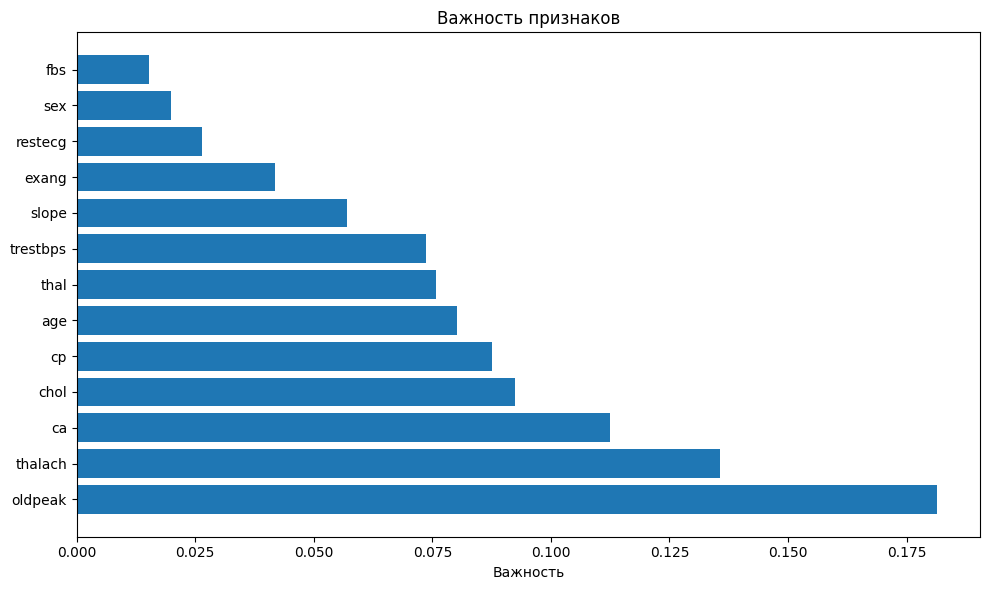


Топ-5 важных признаков:
  1. oldpeak: 0.181
  2. thalach: 0.136
  3. ca: 0.112
  4. chol: 0.092
  5. cp: 0.088


In [12]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel("Важность")
plt.tight_layout()
plt.show()

print("\nТоп-5 важных признаков:")
for i in range(min(5, len(indices))):
    print(f"  {i+1}. {features[indices[i]]}: {importances[indices[i]]:.3f}")